In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import os
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42

# --- Load 4D TIFF Stack ---
tiff_path = r"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/150fr/data/beads0p2um_stack_real_25pow_260218_5fileSum_4D_150fr_hyper.tif"  # Update this path
tiff_path = r"/export/disk1/pooledData/ReLOAD/processed_beads/beads0p2um_stack_real_25pow_260218_5fileSum_4D_150fr_hyper.tif"  # Update this path

# Load the stack
stack = tifffile.imread(tiff_path)

══════════════════════════════════════════════════
  z=4  COM:  x=65.46 px  y=56.81 px
             (4.3468 µm, 3.7722 µm, 4.0 µm)
  z=12  COM:  x=57.20 px  y=45.60 px
             (3.7981 µm, 3.0278 µm, 12.0 µm)

  Δx = -548.7 nm  |  Δy = -744.4 nm  over 8 µm in z
══════════════════════════════════════════════════


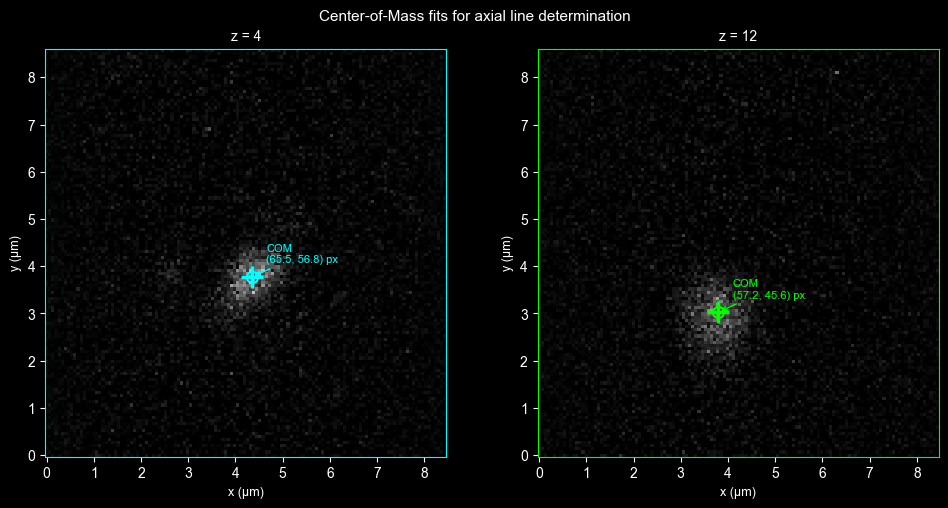

In [2]:
# This code is used to generate the sampling lineout
from scipy.ndimage import center_of_mass
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
k = 18
z1_idx = 4    # first z slice
z2_idx = 12   # second z slice

xy_spacing = 0.0664   # µm/pixel
z_spacing  = 1.0      # µm/slice

# Threshold for COM — only pixels above this fraction of the slice max
# are included. Helps ignore background noise.
com_threshold = 0.3
# ══════════════════════════════════════════════════════════════════════════════

def com_fit(slice_2d, threshold_frac=0.3):
    """
    Compute center of mass of a 2D slice, using only pixels above
    threshold_frac * slice max to suppress background bias.
    Returns (cy_pix, cx_pix) in pixel coordinates.
    """
    thresh = threshold_frac * slice_2d.max()
    masked = np.where(slice_2d > thresh, slice_2d, 0)
    cy, cx = center_of_mass(masked)
    return cy, cx

# Pull slices
vol = stack[k,:,:,:]
slice_z1 = vol[z1_idx, :, :]
slice_z2 = vol[z2_idx, :, :]

# Compute COMs
cy1, cx1 = com_fit(slice_z1, com_threshold)
cy2, cx2 = com_fit(slice_z2, com_threshold)

# Convert to physical units
x1_um = cx1 * xy_spacing
y1_um = cy1 * xy_spacing
z1_um = z1_idx * z_spacing

x2_um = cx2 * xy_spacing
y2_um = cy2 * xy_spacing
z2_um = z2_idx * z_spacing

print("═" * 50)
print(f"  z={z1_idx}  COM:  x={cx1:.2f} px  y={cy1:.2f} px")
print(f"             ({x1_um:.4f} µm, {y1_um:.4f} µm, {z1_um:.1f} µm)")
print(f"  z={z2_idx}  COM:  x={cx2:.2f} px  y={cy2:.2f} px")
print(f"             ({x2_um:.4f} µm, {y2_um:.4f} µm, {z2_um:.1f} µm)")
print()
print(f"  Δx = {(cx2-cx1)*xy_spacing*1000:.1f} nm  |  Δy = {(cy2-cy1)*xy_spacing*1000:.1f} nm  over {z2_um-z1_um:.0f} µm in z")
print("═" * 50)

# ── Visualise ──────────────────────────────────────────────────────────────────
nz, ny, nx = vol.shape
x_ax = np.arange(nx) * xy_spacing
y_ax = np.arange(ny) * xy_spacing

vmin = np.percentile(vol, 1)
vmax = np.percentile(vol, 99.99)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor='black')
fig.suptitle('Center-of-Mass fits for axial line determination',
             color='white', fontsize=11)

titles  = [f'z = {z1_idx}', f'z = {z2_idx}']
slices  = [slice_z1, slice_z2]
coms    = [(cx1, cy1, x1_um, y1_um), (cx2, cy2, x2_um, y2_um)]
colors  = ['cyan', 'lime']

for ax, sl, (cxp, cyp, cxu, cyu), title, color in zip(
        axes, slices, coms, titles, colors):

    ax.pcolormesh(x_ax, y_ax, sl, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_aspect('equal')

    # COM marker
    ax.plot(cxu, cyu, '+', color=color, ms=16, mew=2.5, zorder=5)
    ax.plot(cxu, cyu, 'o', color=color, ms=8, mfc='none', mew=1.5, zorder=5)
    ax.annotate(f'COM\n({cxp:.1f}, {cyp:.1f}) px',
                xy=(cxu, cyu), xytext=(cxu + 0.3, cyu + 0.3),
                color=color, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.set_title(title, color='white', fontsize=10)
    ax.set_xlabel('x (µm)', color='white', fontsize=9)
    ax.set_ylabel('y (µm)', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.set_facecolor('black')
    for sp in ax.spines.values(): sp.set_edgecolor(color)

plt.tight_layout()
# plt.savefig('./bead_visualization_5frame_newzach/300fr/psf_com_check.png', dpi=200, bbox_inches='tight', facecolor='black')
plt.show()

In [4]:
import matplotlib
matplotlib.rcParams['axes.grid'] = False

# ── Global style settings ─────────────────────────────────────────────────────
FONTSIZE  = 3    # axis labels, tick labels
TITLESIZE = 5    # titles
TICKLEN   = 1.5  # tick length
TICKWIDTH = 0.3  # tick width
LW_SPINE  = 0.3  # spine linewidth
LW_FIT    = 0.5  # fit curve linewidth
LW_CROSS  = 0.5  # crosshair linewidth
S_SCATTER = 3    # scatter point size
XY_COLOR = (60/255, 176/255, 161/255)
XZ_COLOR = (165/255, 222/255, 96/255)
# ══════════════════════════════════════════════════════════════════════════════

Using x0=62, y0=51 for XY lineouts
Y:  σ = 322 nm,  FWHM = 758 nm
X:  σ = 427 nm,  FWHM = 1006 nm
Z (axial):  σ = 3190 nm,  FWHM = 7513 nm


/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


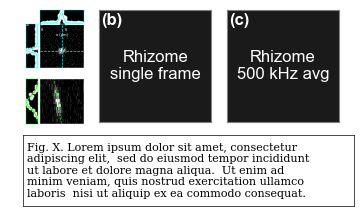

In [5]:
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
k  = 18   # time point
z  = 8    # xy slice z index

cmap = 'gray'

# Use centre slice COM for XY crosshairs
z_centre_idx = nz // 2
cy_centre, cx_centre = com_fit(stack[k,z_centre_idx, :, :], com_threshold)

x0 = int(round(cx_centre))
y0 = int(round(cy_centre))
print(f"Using x0={x0}, y0={y0} for XY lineouts")

xy_spacing = 0.0664  # µm/pixel
z_spacing  = 1  # µm/slice

# Axial line determination
# data from previous code block
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.rcParams['axes.grid'] = False

# ── Slices ────────────────────────────────────────────────────────────────────
xy_slice = stack[k, z,  :,  :]
yz_slice = stack[k, :,  :, x0]
xz_slice = stack[k, :, y0,  :]

nz, ny, nx = stack[k].shape
vmin, vmax = np.percentile(stack[k], 1), np.percentile(stack[k], 99.99)

x_ax = np.arange(nx) * xy_spacing
y_ax = np.arange(ny) * xy_spacing
z_ax = np.arange(nz) * z_spacing

cx_um = x0 * xy_spacing
cy_um = y0 * xy_spacing

def extend_line_to_z_bounds(x1, y1, z1, x2, y2, z2, z_min, z_max):
    """Extend line defined by two points to z_min and z_max."""
    if abs(z2 - z1) < 1e-6:
        return x1, y1, z_min, x2, y2, z_max
    t_min = (z_min - z1) / (z2 - z1)
    t_max = (z_max - z1) / (z2 - z1)
    x_min = x1 + t_min * (x2 - x1)
    x_max = x1 + t_max * (x2 - x1)
    y_min = y1 + t_min * (y2 - y1)
    y_max = y1 + t_max * (y2 - y1)
    return x_min, y_min, z_min, x_max, y_max, z_max

xe1, ye1, ze1, xe2, ye2, ze2 = extend_line_to_z_bounds(
    x1_um, y1_um, z1_um, x2_um, y2_um, z2_um, z_ax[0], z_ax[-1])

# ── Sample 3D line ────────────────────────────────────────────────────────────
def sample_line_3d(stack_k, x1_um, y1_um, z1_um, x2_um, y2_um, z2_um,
                   x_spacing, z_spacing_):
    x1 = x1_um / x_spacing;  x2 = x2_um / x_spacing
    y1 = y1_um / x_spacing;  y2 = y2_um / x_spacing
    z1 = z1_um / z_spacing_; z2 = z2_um / z_spacing_

    dx = x2 - x1; dy = y2 - y1; dz = z2 - z1
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    dx /= length; dy /= length; dz /= length

    nz_, ny_, nx_ = stack_k.shape
    cx = (x1 + x2) / 2; cy = (y1 + y2) / 2; cz = (z1 + z2) / 2

    z_indices = np.arange(nz_).astype(float)
    if abs(dz) > 1e-6:
        t_vals = (z_indices - cz) / dz
    else:
        t_vals = z_indices - nz_ / 2

    xs = cx + t_vals * dx
    ys = cy + t_vals * dy
    zs = cz + t_vals * dz

    mask = (xs >= 0) & (xs < nx_-1) & (ys >= 0) & (ys < ny_-1)

    profile = map_coordinates(stack_k.astype(float),
                              [zs[mask], ys[mask], xs[mask]], order=0)

    t_um = t_vals[mask] * np.sqrt((dx * x_spacing)**2 +
                                   (dy * x_spacing)**2 +
                                   (dz * z_spacing_)**2)
    t_um = t_um - t_um[np.argmax(profile)]

    return t_um, profile

# ── Gaussian ──────────────────────────────────────────────────────────────────
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + offset

def gaussian_z(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2))

def fit_and_plot(ax, t_um, profile, color, xlabel, ylabel, title,
                 extend_fit=False, label=None):
    ax.grid(False)
    ax.scatter(t_um, profile, color='white', s=S_SCATTER, alpha=0.8, zorder=2)
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)],
              1.0, profile.min()]
        popt, _ = curve_fit(gaussian, t_um, profile, p0=p0, maxfev=5000)
        if extend_fit:
            t_fit = np.linspace(t_um.min() * 1.3, t_um.max() * 1.3, 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)
        ax.plot(t_fit, gaussian(t_fit, *popt), color=color, lw=LW_FIT, ls='-',
                label=f'σ = {abs(popt[2])*1000:.0f} nm\nFWHM = {abs(popt[2])*2.355*1000:.0f} nm')
        print(f"{label or xlabel}:  σ = {abs(popt[2])*1000:.0f} nm,  FWHM = {abs(popt[2])*2.355*1000:.0f} nm")
    except Exception as e:
        print(f"Fit failed ({label or xlabel}): {e}")
    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color='white', fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color='white', fontsize=FONTSIZE, labelpad=1)
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(LW_SPINE)

def fit_and_plot_z(ax, t_um, profile, color, xlabel, ylabel, title,
                   extend_fit=False, orientation='horizontal', label=None):
    ax.grid(False)
    if orientation == 'horizontal':
        ax.scatter(t_um, profile, color='white', s=S_SCATTER, alpha=0.8, zorder=2)
    else:
        ax.scatter(profile, t_um, color='white', s=S_SCATTER, alpha=0.8, zorder=2)

    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 1.0, profile.min()]
        popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)
        if extend_fit:
            t_fit = np.linspace(t_um.min()*1.3, t_um.max()*1.3, 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)

        if orientation == 'horizontal':
            ax.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=LW_FIT)
        else:
            ax.plot(gaussian_z(t_fit, *popt), t_fit, color=color, lw=LW_FIT)
            ax.invert_xaxis()

        print(f"{label or xlabel}:  σ = {abs(popt[2])*1000:.0f} nm,  FWHM = {abs(popt[2])*2.355*1000:.0f} nm")
    except Exception as e:
        print(f"Fit failed ({label or xlabel}): {e}")

    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color='white', fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color='white', fontsize=FONTSIZE, labelpad=1)
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(LW_SPINE)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — 3.31 x 2.0 inches (Optica Letters single column, aspect ~1.66)
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(3.31, 2.0), facecolor='white')

gs = gridspec.GridSpec(624, 1036, figure=fig,
                       left=0, right=1,
                       top=1, bottom=0,
                       hspace=0, wspace=0)

ax_xy_lo_y = fig.add_subplot(gs[52:190, 7:45])
ax_xy      = fig.add_subplot(gs[52:190, 52:190])
ax_yz      = fig.add_subplot(gs[225:363, 52:190])
ax_lo_xy_x = fig.add_subplot(gs[7:52, 52:190])
ax_lo_yz   = fig.add_subplot(gs[225:363, 7:45])

ax_rhiz1 = fig.add_subplot(gs[7:357, 237:587])
ax_rhiz2 = fig.add_subplot(gs[7:357, 637:987])

ax_caption = fig.add_subplot(gs[398:620, 0:1036])

# ── XY image ──────────────────────────────────────────────────────────────────
ax_xy.pcolormesh(x_ax, y_ax, xy_slice, cmap=cmap, vmin=vmin, vmax=vmax)
ax_xy.set_aspect('equal')
ax_xy.axhline(cy_um, color='cyan', lw=LW_CROSS, ls='--', alpha=0.9)
ax_xy.axvline(cx_um, color='cyan', lw=LW_CROSS, ls='--', alpha=0.9)
ax_xy.set_xlabel('x (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax_xy.tick_params(colors='white', labelleft=False, labelsize=FONTSIZE,
                  length=TICKLEN, width=TICKWIDTH, pad=1)
ax_xy.set_facecolor('black')
for sp in ax_xy.spines.values(): sp.set_edgecolor('white'); sp.set_linewidth(LW_SPINE)

# ── Y lineout ─────────────────────────────────────────────────────────────────
y_profile = stack[k, z, :, x0]
ax_xy_lo_y.scatter(y_profile, y_ax, color='white', s=S_SCATTER, alpha=0.6, zorder=2)
try:
    p0 = [y_profile.max()-y_profile.min(), y_ax[np.argmax(y_profile)], 0.3, y_profile.min()]
    popt_y, _ = curve_fit(gaussian, y_ax, y_profile, p0=p0, maxfev=5000)
    y_fit = np.linspace(y_ax.min(), y_ax.max(), 500)
    ax_xy_lo_y.plot(gaussian(y_fit, *popt_y), y_fit, color='cyan', lw=LW_FIT)
    print(f"Y:  σ = {abs(popt_y[2])*1000:.0f} nm,  FWHM = {abs(popt_y[2])*2.355*1000:.0f} nm")
except Exception as e:
    print(f"Y fit failed: {e}")
ax_xy_lo_y.set_ylim(y_ax[0], y_ax[-1])
ax_xy_lo_y.invert_xaxis()
ax_xy_lo_y.set_ylabel('y (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax_xy_lo_y.set_xlabel('Int.', color='white', fontsize=FONTSIZE, labelpad=1)
ax_xy_lo_y.set_facecolor('black')
ax_xy_lo_y.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                        width=TICKWIDTH, pad=1)
for sp in ax_xy_lo_y.spines.values(): sp.set_edgecolor('cyan'); sp.set_linewidth(LW_SPINE)

# ── YZ image ──────────────────────────────────────────────────────────────────
ax_yz.pcolormesh(y_ax, z_ax, yz_slice, cmap=cmap, vmin=vmin, vmax=vmax)
ax_yz.set_ylim(z_ax[0], z_ax[-1])
ax_yz.plot([ye1, ye2], [ze1, ze2], color='lime', lw=LW_CROSS, ls='--', alpha=0.9)
ax_yz.set_xlabel('y (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax_yz.set_ylabel('z (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax_yz.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                  width=TICKWIDTH, pad=1)
ax_yz.set_facecolor('black')
for sp in ax_yz.spines.values(): sp.set_edgecolor('white'); sp.set_linewidth(LW_SPINE)

# ── X lineout ─────────────────────────────────────────────────────────────────
fit_and_plot(ax_lo_xy_x, x_ax, stack[k, z, y0, :],
             'cyan', 'x (µm)', 'Intensity', 'XY x line-out',
             extend_fit=False, label='X')

# ── Axial lineout ─────────────────────────────────────────────────────────────
t_um, profile = sample_line_3d(stack[k],
                                x1_um, y1_um, z1_um,
                                x2_um, y2_um, z2_um,
                                xy_spacing, z_spacing)

nz_, ny_, nx_ = stack[k].shape
x1p = x1_um / xy_spacing; y1p = y1_um / xy_spacing; z1p = z1_um / z_spacing
x2p = x2_um / xy_spacing; y2p = y2_um / xy_spacing; z2p = z2_um / z_spacing

fit_and_plot_z(ax_lo_yz, t_um, profile,
               'lime', 'position (µm)', 'Intensity', 'Axial line-out',
               extend_fit=True, orientation='vertical', label='Z (axial)')

# ── Rhizome placeholders ──────────────────────────────────────────────────────
for ax, label, letter in zip([ax_rhiz1, ax_rhiz2],
                               ['Rhizome\nsingle frame', 'Rhizome\n500 kHz avg'],
                               ['(b)', '(c)']):
    ax.set_facecolor('#1a1a1a')
    ax.text(0.5, 0.5, label, ha='center', va='center',
            color='white', fontsize=12, transform=ax.transAxes)
    ax.text(0.02, 0.97, letter, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', color='white')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('gray')

# ── Caption placeholder ───────────────────────────────────────────────────────
import textwrap

caption = ('Fig. X. Lorem ipsum dolor sit amet, consectetur adipiscing elit, \n'
          'sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. \n'
          'Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris \n'
          'nisi ut aliquip ex ea commodo consequat.')
wrapped = textwrap.fill(caption, width=50)

ax_caption.set_xlim(0, 1)
ax_caption.set_ylim(0, 1)
ax_caption.set_facecolor('white')
ax_caption.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for sp in ax_caption.spines.values():
    sp.set_edgecolor('black')
    sp.set_linewidth(0.5)
ax_caption.text(0.01, 0.5, wrapped,
    ha='left', va='center',
    fontsize=8, color='black',
    transform=ax_caption.transAxes,
    family='serif',
    clip_on=True)

# plt.savefig(r"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/300fr/fig5.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

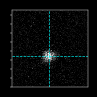

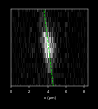

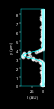

:  σ = 427 nm,  FWHM = 1006 nm


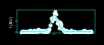

I (AU):  σ = 3190 nm,  FWHM = 7513 nm


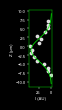

In [6]:
# ── XY image ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.0, 1.0), facecolor='black')
ax.pcolormesh(x_ax, y_ax, xy_slice, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_aspect('equal')
ax.axhline(cy_um, color='cyan', lw=LW_CROSS, ls='--', alpha=0.9)
ax.axvline(cx_um, color='cyan', lw=LW_CROSS, ls='--', alpha=0.9)
ax.set_xlabel('', color='white', fontsize=FONTSIZE, labelpad=1)
ax.tick_params(colors='white', labelleft=False, labelsize=FONTSIZE,
               length=TICKLEN, width=TICKWIDTH, pad=1)
ax.set_facecolor('black')
ax.tick_params(bottom=False, labelbottom=False)
for sp in ax.spines.values(): sp.set_edgecolor('white'); sp.set_linewidth(LW_SPINE)
# plt.tight_layout()
plt.show()

# ── XZ image ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.0, 1.0), facecolor='black')
ax.pcolormesh(x_ax, z_ax, xz_slice, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_ylim(z_ax[0], z_ax[-1])
ax.plot([xe1, xe2], [ze1, ze2], color='lime', lw=LW_CROSS, ls='--', alpha=0.9)
ax.set_xlabel('x (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax.set_ylabel('', color='white', fontsize=FONTSIZE, labelpad=1)
ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN, width=TICKWIDTH, pad=1)
ax.set_facecolor('black')
ax.tick_params(left=False, labelleft=False)
ax.set_xticks([0, 2, 4, 6, 8])
for sp in ax.spines.values(): sp.set_edgecolor('white'); sp.set_linewidth(LW_SPINE)
# plt.tight_layout()
plt.show()

# ── Y lineout ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(0.3, 1.0), facecolor='black')
ax.scatter(y_profile, y_ax, color='white', s=S_SCATTER, alpha=0.6, zorder=2)
try:
    p0 = [y_profile.max()-y_profile.min(), y_ax[np.argmax(y_profile)], 0.3, y_profile.min()]
    popt_y, _ = curve_fit(gaussian, y_ax, y_profile, p0=p0, maxfev=5000)
    y_fit = np.linspace(y_ax.min(), y_ax.max(), 500)
    ax.plot(gaussian(y_fit, *popt_y), y_fit, color='cyan', lw=LW_FIT)
except Exception:
    pass
ax.set_ylim(y_ax[0], y_ax[-1])
ax.invert_xaxis()
ax.set_ylabel('y (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
ax.set_xlabel('I (AU)', color='white', fontsize=FONTSIZE, labelpad=1)
ax.set_facecolor('black')
ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN, width=TICKWIDTH, pad=1)
for sp in ax.spines.values(): sp.set_edgecolor('cyan'); sp.set_linewidth(LW_SPINE)
# plt.tight_layout()
plt.show()

# # ── YZ image ──────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(1.0, 1.0), facecolor='black')
# ax.pcolormesh(y_ax, z_ax, yz_slice, cmap=cmap, vmin=vmin, vmax=vmax)
# ax.set_ylim(z_ax[0], z_ax[-1])
# ax.plot([ye1, ye2], [ze1, ze2], color='lime', lw=LW_CROSS, ls='--', alpha=0.9)
# ax.set_xlabel('y (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
# ax.set_ylabel('z (µm)', color='white', fontsize=FONTSIZE, labelpad=1)
# ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN, width=TICKWIDTH, pad=1)
# ax.set_facecolor('black')
# for sp in ax.spines.values(): sp.set_edgecolor('white'); sp.set_linewidth(LW_SPINE)
# # plt.tight_layout()
# plt.show()

# ── XY x lineout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.0, 0.3), facecolor='black')
fit_and_plot(ax, x_ax, stack[k, z, y0, :],
             'cyan', '', 'I (AU)', 'XY x line-out', extend_fit=False)
ax.tick_params(labelleft=False, labelbottom=False)
# plt.tight_layout()
plt.show()

# ── Axial lineout ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(0.3, 1.0), facecolor='black')
fit_and_plot_z(ax, t_um, profile,
               'lime', 'I (AU)', 'Z (µm)', 'Axial',
               extend_fit=True, orientation='vertical')
# plt.tight_layout()
plt.show()

In [90]:
import matplotlib
matplotlib.rcParams['axes.grid'] = False

# ── Global style settings ─────────────────────────────────────────────────────
FONTSIZE  = 3    # axis labels, tick labels
TITLESIZE = 5    # titles
TICKLEN   = 1.5  # tick length
TICKWIDTH = 0.3  # tick width
LW_SPINE  = 0.3  # spine linewidth
LW_FIT    = 0.5  # fit curve linewidth
LW_CROSS  = 0.5  # crosshair linewidth
S_SCATTER = 3    # scatter point size
XY_COLOR = (60/255, 176/255, 161/255)
XZ_COLOR = (165/255, 222/255, 96/255)
# ══════════════════════════════════════════════════════════════════════════════

In [111]:
#functions
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + offset

def gaussian_z(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2))

def fit_and_plot(ax, t_um, profile, color, xlabel, ylabel, title,
                 extend_fit=False):
    ax.grid(False)
    ax.scatter(t_um, profile, color='white', s=S_SCATTER, marker='.', alpha=0.8, zorder=2, edgecolors='none')
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 1.0, profile.min()]
        popt, _ = curve_fit(gaussian, t_um, profile, p0=p0, maxfev=5000)
        if extend_fit:
            t_fit = np.linspace(t_um.min() , t_um.max() , 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)
        ax.plot(t_fit, gaussian(t_fit, *popt), color=color, lw=LW_FIT, ls='-',
                label=f'σ = {abs(popt[2])*1000:.0f} nm\nFWHM = {abs(popt[2])*2.355*1000:.0f} nm')
    except Exception as e:
        print(f"Fit failed: {e}")
    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color='white', fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color='white', fontsize=FONTSIZE, labelpad=1)
    for sp in ax.spines.values():
        sp.set_visible(False)

def fit_and_plot_z(ax, t_um, profile, color, xlabel, ylabel, title,
                   extend_fit=False, orientation='horizontal'):
    ax.grid(False)
    if orientation == 'horizontal':
        ax.scatter(t_um, profile, color='white', s=S_SCATTER, marker='.', alpha=0.8, zorder=2, edgecolors='none')
    else:
        ax.scatter(profile, t_um, color='white', s=S_SCATTER, marker='.', alpha=0.8, zorder=2, edgecolors='none')
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 1.0, profile.min()]
        popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)
        if extend_fit:
            t_fit = np.linspace(t_um.min()*1.3, t_um.max()*1.3, 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)
        if orientation == 'horizontal':
            ax.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=LW_FIT)
        else:
            ax.plot(gaussian_z(t_fit, *popt), t_fit, color=color, lw=LW_FIT)
            ax.invert_xaxis()
    except Exception as e:
        print(f"Fit failed: {e}")
    ax.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=FONTSIZE, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color='white', fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color='white', fontsize=FONTSIZE, labelpad=1)
    for sp in ax.spines.values():
        sp.set_visible(False)

In [114]:
#functions
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + offset

def gaussian_z(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2))

def fit_and_plot_x1(ax, t_um, profile, color, axisColor, backColor, xlabel, ylabel, title,
                 extend_fit=False):
    ax.grid(False)
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 1.0, profile.min()]
        popt, _ = curve_fit(gaussian, t_um, profile, p0=p0, maxfev=5000)
        print(f'X FWHM = {abs(popt[2])*2.355*1000:.0f} nm')
        if extend_fit:
            t_fit = np.linspace(t_um.min() , t_um.max() , 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)
        ax.plot(t_fit, gaussian(t_fit, *popt), color=color, lw=LW_FIT, ls='-',
                label=f'σ = {abs(popt[2])*1000:.0f} nm\nFWHM = {abs(popt[2])*2.355*1000:.0f} nm')
    except Exception as e:
        print(f"Fit failed: {e}")
    ax.scatter(t_um, profile, color=axisColor, s=S_SCATTER, marker='.', alpha=0.5, zorder=2, edgecolors='none')
    ax.set_facecolor(backColor)
    ax.tick_params(colors=axisColor, labelsize=FONTSIZE-2, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color=axisColor, fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color=axisColor, fontsize=FONTSIZE, labelpad=1)
    # for sp in ax.spines.values():
    #     sp.set_visible(False)
    
def fit_and_plot_y1(ax, t_um, profile, color, axisColor, backColor, xlabel, ylabel, title,
                 extend_fit=False):
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 0.3, profile.min()]
        popt_y, _ = curve_fit(gaussian, t_um, profile, p0=p0, maxfev=5000)
        y_fit = np.linspace(t_um.min(), t_um.max(), 500)
        ax.plot(gaussian(y_fit, *popt_y), y_fit, color=color, lw=LW_FIT)
    except Exception:
        pass
    print(f'Y FWHM = {abs(popt_y[2])*2.355*1000:.0f} nm')
    ax.scatter(profile, t_um, color=axisColor, s=S_SCATTER, marker='.', alpha=0.5, zorder=2, edgecolors='none')
    ax.set_ylim(t_um[0], t_um[-1])
    ax.invert_xaxis()
    ax.set_ylabel('y (µm)', color=axisColor, fontsize=FONTSIZE, labelpad=1)
    ax.set_xlabel('I(AU)', color=axisColor, fontsize=FONTSIZE, labelpad=1)
    ax.set_facecolor(backColor)
    ax.tick_params(colors=axisColor, labelsize=FONTSIZE-2, length=TICKLEN,
                            width=TICKWIDTH, pad=1)
    # ax.set_yticks([0, 2, 4, 6, 8])
    # ax.set_xlabel('')
    # ax.tick_params(bottom=False, labelbottom=True)
    ax.grid(False)
    # for sp in ax_lo_yz.spines.values(): sp.set_visible(False)


def fit_and_plot_z1(ax, t_um, profile, color, axisColor, backColor, xlabel, ylabel, title,
                   extend_fit=False, orientation='horizontal'):
    ax.grid(False)
    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 1.0, profile.min()]
        popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)
        print(f'Z FWHM = {abs(popt[2])*2.355*1000:.0f} nm')
        if extend_fit:
            t_fit = np.linspace(t_um.min()*1.3, t_um.max()*1.3, 500)
        else:
            t_fit = np.linspace(t_um.min(), t_um.max(), 500)
        if orientation == 'horizontal':
            ax.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=LW_FIT,alpha=1)
        else:
            ax.plot(gaussian_z(t_fit, *popt), t_fit, color=color, lw=LW_FIT)
            ax.invert_xaxis()
    except Exception as e:
        print(f"Fit failed: {e}")
    if orientation == 'horizontal':
        ax.scatter(t_um, profile, color=axisColor, s=S_SCATTER, marker='.', alpha=0.5, zorder=2, edgecolors='none')
    else:
        ax.scatter(profile, t_um, color=axisColor, s=S_SCATTER, marker='.', alpha=0.5, zorder=2, edgecolors='none')
    ax.set_facecolor(backColor)
    ax.tick_params(colors=axisColor, labelsize=FONTSIZE-2, length=TICKLEN,
                   width=TICKWIDTH, pad=1)
    ax.set_xlabel(xlabel, color=axisColor, fontsize=FONTSIZE, labelpad=1)
    ax.set_ylabel(ylabel, color=axisColor, fontsize=FONTSIZE, labelpad=1)
    # for sp in ax.spines.values():
    #     sp.set_visible(False)

In [115]:
def imshow_cleanup(ax,fullClean=True,faceClean=True):
    if fullClean:
        ax.axes.xaxis.set_visible(False)
        ax.axes.yaxis.set_visible(False)
    if faceClean:
        ax.set_facecolor('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    return ax
def clean_subplots(nrows,ncols,figsize = False, facecolor='none', constrained_layout = True, tight_layout = False, sharey = False, sharex = False):
    
    
    if figsize:
        fig,ax = plt.subplots(nrows,ncols,figsize=figsize,tight_layout=tight_layout,sharey=sharey,sharex=sharex)
    else:
        fig,ax = plt.subplots(nrows,ncols,tight_layout=tight_layout,sharey=sharey,sharex=sharex)
    if hasattr(ax, 'shape'):
        if len(ax.shape)>1:
            for row in range(ax.shape[0]):
                for col in range(ax.shape[1]):
                    ax[row,col].set_facecolor(facecolor)
                    if facecolor=='none':
                        ax[row,col].patch.set_alpha(0.0) # Axes background
        else:
            for row in range(ax.shape[0]):
                ax[row].set_facecolor(facecolor)
                if facecolor=='none':
                    ax[row].patch.set_alpha(0.0) # Axes background
    else:
        ax.set_facecolor(facecolor)
        if facecolor=='none':
            ax.patch.set_alpha(0.0) # Axes background
    if constrained_layout:
        fig.set_constrained_layout(True)
    fig.set_facecolor(facecolor)
    if facecolor=='none':
        fig.patch.set_alpha(0.0) # Figure background
    return fig,ax


xz_extent
[0.0, 8.4328, 0, 15]
4.6211571936325315
3.5923072027455865
[4.6211571936325315, 3.5923072027455865]
[0, 15]


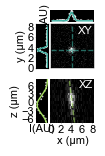

In [141]:
figDir = "/export/disk1/pooledData/ReLOAD/processed_beads/"
figName = "ReLOAD_2P_PSF_150_DEANO.pdf"

figsize=list(np.array([5,3])*0.66)
# figsize=list(np.array([5,3])*10)
fig = plt.figure(figsize=figsize, facecolor='white')

gs = gridspec.GridSpec(624, 1036, figure=fig,
                       left=0, right=1, top=1, bottom=0,
                       hspace=0, wspace=0)

ax_xy_lo_y = fig.add_subplot(gs[52:190,  7:45])
ax_xy      = fig.add_subplot(gs[52:190, 52:190])
ax_xz      = fig.add_subplot(gs[225:363, 52:190])
ax_lo_xy_x = fig.add_subplot(gs[7:45,   52:190])
ax_lo_yz   = fig.add_subplot(gs[225:363,  7:45])

# ── XY image ──────────────────────────────────────────────────────────────────
ax_xy.pcolormesh(x_ax, y_ax, xy_slice, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
ax_xy.set_aspect('equal')
ax_xy.axhline(cy_um, color=XY_COLOR, lw=LW_CROSS, ls='--', alpha=0.6)
ax_xy.axvline(cx_um, color=XY_COLOR, lw=LW_CROSS, ls='--', alpha=0.6)
ax_xy.set_xlabel('', fontsize=FONTSIZE, labelpad=1)
ax_xy.tick_params(colors='black', labelleft=False, labelsize=FONTSIZE,
                  length=TICKLEN, width=TICKWIDTH, pad=1)
ax_xy.tick_params(bottom=False, labelbottom=False)
ax_xy.tick_params(left=False)
ax_xy.set_facecolor('black')
for sp in ax_xy.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(LW_SPINE)
ax_xy.text(0.97, 0.97, 'XY', transform=ax_xy.transAxes,
           ha='right', va='top', color='white', fontsize=FONTSIZE)

# ── Y lineout ─────────────────────────────────────────────────────────────────
ax_xy_lo_y.scatter(y_profile, y_ax, color='white', s=S_SCATTER, marker='.', alpha=0.8, zorder=2, edgecolors='none')
try:
    p0 = [y_profile.max()-y_profile.min(), y_ax[np.argmax(y_profile)], 0.3, y_profile.min()]
    popt_y, _ = curve_fit(gaussian, y_ax, y_profile, p0=p0, maxfev=5000)
    y_fit = np.linspace(y_ax.min(), y_ax.max(), 500)
    ax_xy_lo_y.plot(gaussian(y_fit, *popt_y), y_fit, color=XY_COLOR, lw=LW_FIT)
except Exception:
    pass
ax_xy_lo_y.set_ylim(y_ax[0], y_ax[-1])
ax_xy_lo_y.invert_xaxis()
ax_xy_lo_y.set_ylabel('y (µm)', color='black', fontsize=FONTSIZE, labelpad=1)
ax_xy_lo_y.set_xlabel('I(AU)', color='black', fontsize=FONTSIZE, labelpad=1)
ax_xy_lo_y.set_facecolor('black')
ax_xy_lo_y.tick_params(colors='black', labelsize=FONTSIZE, length=TICKLEN,
                        width=TICKWIDTH, pad=1)
ax_xy_lo_y.set_yticks([0, 2, 4, 6, 8])
ax_xy_lo_y.set_xlabel('')
ax_xy_lo_y.tick_params(bottom=False, labelbottom=False)
ax_xy_lo_y.grid(False)
for sp in ax_lo_yz.spines.values(): sp.set_visible(False)

# ── XZ image ──────────────────────────────────────────────────────────────────
# ax_xz.pcolormesh(x_ax, z_ax, xz_slice, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
print(f'xz_extent')
print([x_ax[0], x_ax[-1], z_ax[0], z_ax[-1]])

ax_xz.imshow(np.flipud(xz_slice), cmap=cmap, vmin=vmin, vmax=vmax,
             extent=[x_ax[0], x_ax[-1], z_ax[0], z_ax[-1]],
             aspect='auto', origin='upper', interpolation='none')

print(xe1)
print(xe2)
ax_xz.set_ylim(z_ax[0], z_ax[-1])
ax_xz.plot([xe1, xe2], [ze1, ze2], color=XZ_COLOR, lw=LW_CROSS, ls='--', alpha=0.6)
print([xe1, xe2])
print([ze1, ze2])

ax_xz.set_xlabel('x (µm)', color='black', fontsize=FONTSIZE, labelpad=1)
ax_xz.set_ylabel('', fontsize=FONTSIZE, labelpad=1)
ax_xz.set_xticks([0, 2, 4, 6, 8])
ax_xz.tick_params(colors='black', labelsize=FONTSIZE, length=TICKLEN,
                  width=TICKWIDTH, pad=1, left=False, labelleft=False)
ax_xz.set_facecolor('black')
for sp in ax_xz.spines.values(): sp.set_visible(False)
ax_xz.text(0.97, 0.97, 'XZ', transform=ax_xz.transAxes,
           ha='right', va='top', color='white', fontsize=FONTSIZE)

# ── XY x lineout ──────────────────────────────────────────────────────────────
fit_and_plot(ax_lo_xy_x, x_ax, stack[k, z, y0, :],
             XY_COLOR, '', 'I(AU)', 'XY x line-out', extend_fit=False)
ax_lo_xy_x.tick_params(colors='black', labelleft=False, labelbottom=False)
ax_lo_xy_x.yaxis.label.set_color('black')
ax_lo_xy_x.xaxis.label.set_color('black')
for sp in ax_lo_xy_x.spines.values(): sp.set_visible(False)
ax_lo_xy_x.grid(False)
ax_lo_xy_x.tick_params(left=False, bottom=False)
ax_lo_xy_x.set_axisbelow(False)
plt.rcParams['axes.grid'] = False

# ── Axial lineout ─────────────────────────────────────────────────────────────
fit_and_plot_z(ax_lo_yz, t_um, profile,
               XZ_COLOR, 'I(AU)', 'z (µm)', 'Axial',
               extend_fit=True, orientation='vertical')
ax_lo_yz.tick_params(colors='black')
ax_lo_yz.yaxis.label.set_color('black')
ax_lo_yz.xaxis.label.set_color('black')
ax_lo_yz.grid(False)
ax_lo_yz.set_yticks([-6, -3, 0, 3, 6])
ax_lo_yz.set_ylim(-7.5,8.5)
ax_lo_yz.tick_params(bottom=False, labelbottom=False)
for sp in ax_lo_yz.spines.values(): sp.set_visible(False)

with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

plt.show()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
82
82
xz_extent [0.0, 8.4328, 0, 16]
xz_extent [0.0, 8.4328, 0, 16]
xz_extent [0.0, 8.5656, 0, 16]
xz_aspect 0.5
yz_aspect 0.5
Y FWHM = 758 nm
X FWHM = 1006 nm
z_um2
[4.6211571936325315, 3.5923072027455865]
[0, 15]
1.328
z_um2
[4.144339061617114, 2.748649042964187]
[0, 15]
Z FWHM = 7513 nm


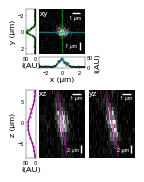

In [180]:
figDir = "/export/disk1/pooledData/ReLOAD/processed_beads/"
figName = "ReLOAD_2P_PSF_150.pdf"

plotLims = [-2,52]
xy_um = 1
z_um = 2

figsize=list(np.array([2,3])*0.5)

# figsize=(8,12)


S_SCATTER = 7
FONTSIZE = 6
LW_CROSS = 1
LW_FIT = 1
TICKLEN = 0.5
TICKWIDTH = 0.25
AX_LW = 0.25
X_COLOR = (0,0.75,0.75)
Y_COLOR = (0,0.75,0)
Z_COLOR = (0.75,0,0.7)

cx_um = x0 * xy_spacing
cy_um = y0 * xy_spacing

nz, ny, nx = stack[k].shape
vmin, vmax = np.percentile(stack[k], 1), np.percentile(stack[k], 99.99)

x_ax = np.arange(nx) * xy_spacing
y_ax = np.arange(ny) * xy_spacing
z_ax = np.arange(nz) * z_spacing

print(z_ax)


nRows = 3
nCols = 3
fig,ax=clean_subplots(nRows,nCols,figsize=figsize,constrained_layout=True)
xy_extent = [0, nx * xy_spacing, ny * xy_spacing, 0]
# print(xy_extent)
# print(xy_aspect)
# xz_extent = [0, nx * xy_spacing, nz * z_spacing, 0]

y_lim_idx = [10,92]
x_lim_idx  = [20,102]
print(x_lim_idx[1]-x_lim_idx[0])
print(y_lim_idx[1]-y_lim_idx[0])
xy_extent = [x_lim_idx[0]* xy_spacing, x_lim_idx[1] * xy_spacing, y_lim_idx[1] * xy_spacing, y_lim_idx[0]* xy_spacing ]
print(f'xz_extent {xz_extent}')
# xz_extent = [x_lim_idx[0]* xy_spacing, x_lim_idx[1] * xy_spacing, nz * z_spacing, 0]
# xz_extent = [x_lim_idx[0]* xy_spacing, x_lim_idx[1] * xy_spacing, nz * z_spacing, 0]
# xz_extent = [x_lim_idx[0]* xy_spacing, x_lim_idx[1] * xy_spacing, z_ax[0], z_ax[-1]]
xz_extent = [x_ax[0], x_ax[-1], z_ax[0], z_ax[-1]+1]
print(f'xz_extent {xz_extent}')
# yz_extent = [y_lim_idx[0]* xy_spacing, y_lim_idx[1] * xy_spacing, z_ax[0], z_ax[-1]]
yz_extent = [y_ax[0], y_ax[-1], z_ax[0], z_ax[-1]+1]
print(f'xz_extent {yz_extent}')

actual_y = np.arange(y_lim_idx[0]* xy_spacing , y_lim_idx[1] * xy_spacing, xy_spacing)
actual_x = np.arange(x_lim_idx[0]* xy_spacing , x_lim_idx[1] * xy_spacing, xy_spacing)

xy_aspect = (len(actual_x) * xy_spacing)/(len(actual_y) * xy_spacing)


# xz_aspect = (nz * z_spacing)/(len(actual_x) * xy_spacing)
xz_aspect = 0.5
yz_aspect = 0.5
print(f'xz_aspect {xz_aspect}')
print(f'yz_aspect {yz_aspect}')


row = 1
col = 0
fig.delaxes(ax[row,col])

row = 0
col = 2
fig.delaxes(ax[row,col])
row = 1
col = 2
fig.delaxes(ax[row,col])

# ── XY image ──────────────────────────────────────────────────────────────────
row=0
col=1
ax[row,col].imshow(xy_slice[y_lim_idx[0]:y_lim_idx[1],x_lim_idx[0]:x_lim_idx[1]], \
                   extent = xy_extent, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='none',aspect=xy_aspect)
ax[row,col].text(xy_extent[0]+xy_spacing,xy_extent[3]+xy_spacing,'xy',color=(1,1,1),fontsize=FONTSIZE,ha='left',va='top')
# ax[row,col].set_ylim([0,ny * xy_spacing])
# ax[row,col].set_xlim([0,nx * xy_spacing])
ax[row,col].axhline(cy_um, color=X_COLOR, lw=LW_CROSS, ls='-', alpha=0.6)
ax[row,col].axvline(cx_um, color=Y_COLOR, lw=LW_CROSS, ls='-', alpha=0.6)
#vert
ax[row,col].plot([xy_extent[1]-0.5,xy_extent[1]-0.5],[xy_extent[2]-0.5,xy_extent[2]-0.5-xy_um],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text(xy_extent[1]-0.7,xy_extent[2]-0.5-xy_um/2,str(xy_um)+' μm ',color=(1,1,1),fontsize=FONTSIZE-2,ha='right',va='center')

#horz
ax[row,col].plot([xy_extent[1]-0.5,xy_extent[1]-0.5-xy_um],[xy_extent[3]+0.5,xy_extent[3]+0.5],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text(xy_extent[1]-0.5-xy_um/2,xy_extent[3]+0.7,str(xy_um)+' μm ',color=(1,1,1),fontsize=FONTSIZE-2,ha='center',va='top')


ax[row,col] = imshow_cleanup(ax[row,col],True,True)
ax_xy_pos = ax[row,col].get_position()
# print([-xy_spacing/2,ny * xy_spacing+xy_spacing/2])
ax[row,col].set_position([0.5,0.7,0.5,0.3])
ax_xy_pos = ax[row,col].get_position()

# ── Y lineout ─────────────────────────────────────────────────────────────────
row=0
col=0

fit_and_plot_y1(ax[row,col], y_ax - cy_um, stack[k, z, :, x0],
             Y_COLOR, (0,0,0),'none','I(AU)', 'I(AU)', 'XY x line-out', extend_fit=False)
# ax[row,col].set_ylim([])
ax[row,col].set_ylim([y_lim_idx[1]* xy_spacing - cy_um,y_lim_idx[0] * xy_spacing - cy_um])
ax[row,col].set_xlim([plotLims[1],plotLims[0]])
for sp in ax[row,col].spines.values():
    sp.set_linewidth(AX_LW)
ax_xy_y_pos = ax[row,col].get_position()
ax[row,col].set_yticks([-2,0,2])
# ax[row,col].set_position([ax_xy_pos.x0,ax_xz_pos.y0,ax_xy_pos.width,ax_xz_pos.height])
# ax[row,col].set_position([ax_xy_pos.x0,)
ax[row,col].set_position([0.39,0.7,0.1,0.3])

# ── X lineout ──────────────────────────────────────────────────────────────
row=1
col=1

fit_and_plot_x1(ax[row,col], x_ax - cx_um, stack[k, z, y0, :],
             X_COLOR, (0,0,0),'none','x (µm)', 'I(AU)', 'XY x line-out', extend_fit=False)
ax[row,col].set_xlim([x_lim_idx[0]* xy_spacing - cx_um,x_lim_idx[1] * xy_spacing - cx_um])
ax[row,col].set_ylim([plotLims[0],plotLims[1]])
ax[row,col].yaxis.tick_right()
ax[row,col].yaxis.set_label_position("right")

for sp in ax[row,col].spines.values():
    sp.set_linewidth(AX_LW)
ax_xy_x_pos = ax[row,col].get_position()
ax[row,col].set_position([ax_xy_pos.x0,0.61,ax_xy_pos.width,0.07])
ax[row,col].set_xticks([-2,0,2])
# ax[row,col].set_ylabel('')
# ax[row,col].spines['left'].set_linewidth(2)
# ax[row,col].spines['bottom'].set_linewidth(2)
# ax[row,col].spines['right'].set_linewidth(0.5)
# ax[row,col].spines['top'].set_linewidth(0.5)

# ── XZ image ──────────────────────────────────────────────────────────────────
row=2
col=1
ax[row,col].imshow(np.flipud(xz_slice), extent = xz_extent, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='none',aspect=xz_aspect)
ax[row,col].text( x_lim_idx[0] * xy_spacing,xz_extent[3],"xz",color=(1,1,1),fontsize=FONTSIZE,ha='left',va='top')
# ax[row,col].invert_xaxis()
#vert
print(f'z_um{z_um}')
ax[row,col].plot([ x_lim_idx[1] * xy_spacing-0.5, x_lim_idx[1] * xy_spacing-0.5],[xz_extent[2]+1,xz_extent[2]+1+z_um],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text( x_lim_idx[1] * xy_spacing-0.7,xz_extent[2]+1+z_um/2,str(z_um)+' μm',color=(1,1,1),fontsize=FONTSIZE-2,ha='right',va='center')

# #horz
ax[row,col].plot([ x_lim_idx[1] * xy_spacing-0.5, x_lim_idx[1] * xy_spacing-0.5-xy_um],[xz_extent[3]-1,xz_extent[3]-1],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text( x_lim_idx[1] * xy_spacing-0.5-xy_um/2,xz_extent[3]-1.2,str(xy_um)+' μm ',color=(1,1,1),fontsize=FONTSIZE-2,ha='center',va='top')

# ax[row,col].set_ylim([0,nz * z_spacing])
ax[row,col].set_xlim([x_lim_idx[0]* xy_spacing, x_lim_idx[1] * xy_spacing])
print([xe1, xe2])
print([ze1, ze2])
ax[row,col].plot([xe1, xe2], [ze1+0.5, ze2+0.5], color=Z_COLOR, lw=LW_CROSS, ls='-', alpha=0.6)
ax[row,col] = imshow_cleanup(ax[row,col],True,True)
ax_xz_pos = ax[row,col].get_position()
# print(ax_xz_pos)
ax[row,col].set_position([0.5,0.01,0.5,0.45])
# ax[row,col].set_position([ax_xy_pos.x0,ax_xz_pos.y0,ax_xy_pos.width,ax_xz_pos.height])

# ── YZ image ──────────────────────────────────────────────────────────────────
row=2
col=2
print(x_lim_idx[0] * xy_spacing)

ax[row,col].imshow(np.flipud(yz_slice), extent = yz_extent, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='none',aspect=yz_aspect)
ax[row,col].text( y_lim_idx[0] * xy_spacing,yz_extent[3],"yz",color=(1,1,1),fontsize=FONTSIZE,ha='left',va='top')
# ax[row,col].invert_xaxis()
#vert
print(f'z_um{z_um}')
ax[row,col].plot([ y_lim_idx[1] * xy_spacing-0.5, y_lim_idx[1] * xy_spacing-0.5],[yz_extent[2]+1,yz_extent[2]+1+z_um],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text( y_lim_idx[1] * xy_spacing-0.7,yz_extent[2]+1+z_um/2,str(z_um)+' μm',color=(1,1,1),fontsize=FONTSIZE-2,ha='right',va='center')

# #horz
ax[row,col].plot([ y_lim_idx[1] * xy_spacing-0.5, y_lim_idx[1] * xy_spacing-0.5-xy_um],[yz_extent[3]-1,yz_extent[3]-1],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[row,col].text( y_lim_idx[1] * xy_spacing-0.5-xy_um/2, yz_extent[3]-1.2,str(xy_um)+' μm ',color=(1,1,1),fontsize=FONTSIZE-2,ha='center',va='top')

# ax[row,col].set_ylim([0,nz * z_spacing])
ax[row,col].set_xlim([y_lim_idx[0]* xy_spacing, y_lim_idx[1] * xy_spacing])
print([ye1, ye2])
print([ze1, ze2])
ax[row,col].plot([ye1, ye2], [ze1+0.5, ze2+0.5], color=Z_COLOR, lw=LW_CROSS, ls='-', alpha=0.6)
ax[row,col] = imshow_cleanup(ax[row,col],True,True)
ax_xz_pos = ax[row,col].get_position()
# print(ax_xz_pos)
ax[row,col].set_position([1,0.01,0.5,0.45])
# ax[row,col].set_position([ax_xy_pos.x0,ax_xz_pos.y0,ax_xy_pos.width,ax_xz_pos.height])


# ── Axial lineout ─────────────────────────────────────────────────────────────
row=2
col=0
t_um, z_profile = sample_line_3d(stack[k],
                                x1_um, y1_um, z1_um,
                                x2_um, y2_um, z2_um,
                                xy_spacing, z_spacing)
fit_and_plot_z1(ax[row,col], t_um, z_profile,
               Z_COLOR, (0,0,0),'none','I(AU)', 'z (µm)', 'Axial',
               extend_fit=True, orientation='vertical')
ax[row,col].set_ylim([t_um[0]-z_spacing/2,t_um[-1]+z_spacing/2])
ax[row,col].set_xlim([plotLims[1],plotLims[0]])
for sp in ax[row,col].spines.values():
    sp.set_linewidth(AX_LW)
ax_xz_z_pos = ax[row,col].get_position()
ax[row,col].set_position([0.39,0.01,0.1,0.45])
# ax[row,col].set_yticks([-6,-4,-2,0, 2, 4, 6, 8])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [127]:
print([xe1, xe2])


[4.6211571936325315, 3.5923072027455865]
